In [ ]:
import io
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor as DTR
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

!pip install xgboost
from xgboost import XGBRegressor

In [ ]:
data1 = pd.read_csv('/content/drive/MyDrive/training.csv')
print(data1.shape)

data2 = pd.read_csv('/content/drive/MyDrive/test.csv')
print(data2.shape)

data = pd.concat([data1, data2], ignore_index=True)
print(data.shape)
print(data.head())

(1060, 81)
(400, 81)
(1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   3          60       RL         68.0    11250   Pave   NaN      IR1   
2   4          70       RL         60.0     9550   Pave   NaN      IR1   
3   5          60       RL         84.0    14260   Pave   NaN      IR1   
4   8          60       RL          NaN    10382   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   
4         Lvl    AllPub  ...        0    NaN   NaN        Shed     350     11   

  YrSold  SaleType  SaleCondition  S

In [ ]:
data = data.dropna(thresh=len(data) - 300, axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [ ]:
null_counts = data.isnull().sum()
null_counts = null_counts[null_counts != 0]

dtypes = data.dtypes[null_counts.index]

result = pd.DataFrame({'Null Counts': null_counts, 'Data Type': dtypes})
result

,Null Counts,Data Type
LotFrontage,259,float64
MasVnrArea,8,float64
BsmtQual,37,object
BsmtCond,37,object
BsmtExposure,38,object
BsmtFinType1,37,object
BsmtFinType2,38,object
Electrical,1,object
GarageType,81,object
GarageYrBlt,81,float64


In [ ]:
# missing values (median for numerical, mode for object)
for column in data.select_dtypes(include=['float64']).columns:
    data[column] = data[column].fillna(data[column].median())

for column in data.select_dtypes(include=['object']).columns:
    data[column] = data[column].fillna(data[column].mode()[0])
null_counts = data.isnull().sum()
null_counts = null_counts[null_counts != 0]
null_counts

,0


In [ ]:
# Prepare Object data for encoding
obj_data = data.select_dtypes(include=['object']).copy()
data = data.drop(columns=obj_data.columns)
obj_data

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,Electrical,KitchenQual,Functional,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
1,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,SBrkr,Gd,Typ,Detchd,Unf,TA,TA,Y,WD,Abnorml
3,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
4,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,...,SBrkr,TA,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,...,SBrkr,TA,Typ,Detchd,Unf,TA,TA,Y,WD,Normal
1456,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
1457,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,NAmes,Norm,Norm,...,SBrkr,TA,Typ,Attchd,Unf,TA,TA,Y,WD,Normal
1458,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,...,SBrkr,Ex,Typ,Attchd,Fin,TA,TA,Y,New,Partial


In [ ]:
# Unique value count in object data
for column in obj_data.columns:
    print(f"{column}, Unique Vals: {obj_data[column].nunique()}")

MSZoning, Unique Vals: 5
Street, Unique Vals: 2
LotShape, Unique Vals: 4
LandContour, Unique Vals: 4
Utilities, Unique Vals: 2
LotConfig, Unique Vals: 5
LandSlope, Unique Vals: 3
Neighborhood, Unique Vals: 25
Condition1, Unique Vals: 9
Condition2, Unique Vals: 8
BldgType, Unique Vals: 5
HouseStyle, Unique Vals: 8
RoofStyle, Unique Vals: 6
RoofMatl, Unique Vals: 8
Exterior1st, Unique Vals: 15
Exterior2nd, Unique Vals: 16
ExterQual, Unique Vals: 4
ExterCond, Unique Vals: 5
Foundation, Unique Vals: 6
BsmtQual, Unique Vals: 4
BsmtCond, Unique Vals: 4
BsmtExposure, Unique Vals: 4
BsmtFinType1, Unique Vals: 6
BsmtFinType2, Unique Vals: 6
Heating, Unique Vals: 6
HeatingQC, Unique Vals: 5
CentralAir, Unique Vals: 2
Electrical, Unique Vals: 5
KitchenQual, Unique Vals: 4
Functional, Unique Vals: 7
GarageType, Unique Vals: 6
GarageFinish, Unique Vals: 3
GarageQual, Unique Vals: 5
GarageCond, Unique Vals: 5
PavedDrive, Unique Vals: 3
SaleType, Unique Vals: 9
SaleCondition, Unique Vals: 6


In [ ]:
# Drop columns with mnay unique vals
obj_data = obj_data.drop(columns={'Neighborhood','Exterior1st','Exterior2nd'})
obj_data=pd.get_dummies(obj_data,prefix='fet')
obj_data=obj_data.replace({False:0,True:1})

data = pd.concat([data, obj_data], axis=1)
print(data.shape)
data.head()

(1460, 212)


<ipython-input-86-386fcb048771>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  obj_data=obj_data.replace({False:0,True:1})


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,fet_ConLw,fet_New,fet_Oth,fet_WD,fet_Abnorml,fet_AdjLand,fet_Alloca,fet_Family,fet_Normal,fet_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,0,0,1,0,0,0,0,1,0
1,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,0,0,1,0,0,0,0,1,0
2,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,0,0,1,1,0,0,0,0,0
3,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,0,0,0,1,0,0,0,0,1,0
4,8,60,69.0,10382,7,6,1973,1973,240.0,859,...,0,0,0,1,0,0,0,0,1,0


In [ ]:
def drop_highly_correlated_features(data, threshold=0.75):

    corr_matrix = data.drop(columns=['SalePrice']).corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    data = data.drop(columns=to_drop)

    return data

data = drop_highly_correlated_features(data)
data.shape

(1460, 119)

In [ ]:
# Splitting data into the orginal train/test split and scale
y=data['SalePrice']
X=data.drop(columns=['SalePrice'])

X_train = X[:1060]
X_test = X[1060:]
y_train = y[:1060]
y_test = y[1060:]

scaler = StandardScaler()
for col in X_train.columns:
    X_train[col] = scaler.fit_transform(X_train[[col]])
for col in X_test.columns:
    X_test[col] = scaler.fit_transform(X_test[[col]])

In [ ]:
# Inital fitting of training data using lr
y=y_train
x = X_train
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
model.summary()

# R2=0.872 , Adj. R2=0.857

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     57.23
Date:                Mon, 12 May 2025   Prob (F-statistic):               0.00
Time:                        04:27:32   Log-Likelihood:                -12379.
No. Observations:                1060   AIC:                         2.499e+04
Df Residuals:                     946   BIC:                         2.555e+04
Df Model:                         113                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1.805e+05    928.583    194.358      0.000    1.79e+05    1.82e+05
Id              165.7691    984.008      0.168      0.866   -1765.322    2096.860
MSSubClass    -7042.7634   4134.968     -1.703      0.089   -1.52e+04    1072.008
LotFrontage    5327.4898   1453.928      3.664      0.000    2474.193    8180.786
LotArea        1833.4731   1282.061      1.430      0.153    -682.539    4349.486
OverallQual    1.718e+04   1882.705      9.125      0.000    1.35e+04    2.09e+04
OverallCond    5553.4148   1380.013      4.024      0.000    2845.175    8261.655
YearBuilt      5175.0479   2615.444      1.979      0.048      42.305    1.03e+04
YearRemodAdd   2873.7060   1560.914      1.841      0.066    -189.548    5936.960
MasVnrArea     3819.2952   1167.335      3.272      0.001    1528.430    6110.160
BsmtFinSF1     8380.3073   1305.498      6.419      0.000    5818.301    1.09e+04
BsmtFinSF2      636.4401   1015.150      0.627      0.531   -1355.766    2628.646
BsmtUnfSF      -429.6811   1109.680     -0.387      0.699   -2607.400    1748.038
TotalBsmtSF    8329.0016   1811.004      4.599      0.000    4774.951    1.19e+04
X2ndFlrSF      1129.4114   3366.129      0.336      0.737   -5476.531    7735.354
LowQualFinSF   -420.7562   1249.945     -0.337      0.736   -2873.742    2032.230
GrLivArea       3.29e+04   3656.381      8.997      0.000    2.57e+04    4.01e+04
BsmtFullBath   1150.3570   1500.711      0.767      0.444   -1794.751    4095.465
BsmtHalfBath   -312.9930   1057.922     -0.296      0.767   -2389.138    1763.152
FullBath        238.4791   1730.897      0.138      0.890   -3158.363    3635.321
HalfBath          7.4961   1515.899      0.005      0.996   -2967.418    2982.410
BedroomAbvGr  -3273.2611   1429.050     -2.291      0.022   -6077.735    -468.787
KitchenAbvGr  -3754.8064   1939.666     -1.936      0.053   -7561.352      51.740
Fireplaces     2980.3945   1234.952      2.413      0.016     556.833    5403.956
GarageCars     5641.6971   1512.294      3.731      0.000    2673.858    8609.536
WoodDeckSF     1576.0907   1078.554      1.461      0.144    -540.545    3692.726
OpenPorchSF    -619.5086   1118.451     -0.554      0.580   -2814.440    1575.423
EnclosedPorch   660.1088   1122.748      0.588      0.557   -1543.255    2863.473
X3SsnPorch     1057.9775    991.773      1.067      0.286    -888.353    3004.308
ScreenPorch    1163.1356   1015.211      1.146      0.252    -829.191    3155.462
PoolArea       4662.6945   1093.102      4.266      0.000    2517.510    6807.879
MiscVal          -9.2843    967.312     -0.010      0.992   -1907.610    1889.042
MoSold        -1167.1119    995.319     -1.173      0.241   -3120.401     786.177
YrSold          905.8276   1011.118      0.896      0.371   -1078.467    2890.122
fet_C (all)   -1275.5646   1116.443     -1.143   

In [ ]:
#Dropping features with p-val>0.20
p_values = model.pvalues

# list of features to remove
features_to_remove = []
for feature, p_value in p_values.items():
    if p_value > 0.20 and feature != 'const':
        features_to_remove.append(feature)

X_train = X_train.drop(columns=features_to_remove)
X_test = X_test.drop(columns=features_to_remove)
X_train.shape, X_test.shape

((1060, 44), (400, 44))

In [ ]:
# Inital fitting of training data using lr after dropping
x = X_train
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
model.summary()

# R2=0.866 , Adj. R2=0.86

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     152.1
Date:                Mon, 12 May 2025   Prob (F-statistic):               0.00
Time:                        04:27:39   Log-Likelihood:                -12407.
No. Observations:                1060   AIC:                         2.490e+04
Df Residuals:                    1016   BIC:                         2.512e+04
Df Model:                          43                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.805e+05    919.693    196.237      0.000    1.79e+05    1.82e+05
MSSubClass   -3326.6310   1252.493     -2.656      0.008   -5784.401    -868.861
LotFrontage   4343.4399   1270.600      3.418      0.001    1850.139    6836.741
LotArea       1675.0932   1093.992      1.531      0.126    -471.649    3821.836
OverallQual   1.698e+04   1781.243      9.532      0.000    1.35e+04    2.05e+04
OverallCond   5306.2965   1244.221      4.265      0.000    2864.760    7747.833
YearBuilt     6051.2591   1834.208      3.299      0.001    2451.990    9650.528
YearRemodAdd  3206.1468   1444.399      2.220      0.027     371.799    6040.494
MasVnrArea    4047.7356   1101.845      3.674      0.000    1885.584    6209.888
BsmtFinSF1    9795.1561   1206.668      8.118      0.000    7427.310    1.22e+04
TotalBsmtSF   7520.1616   1623.097      4.633      0.000    4335.155    1.07e+04
GrLivArea     3.349e+04   1864.659     17.962      0.000    2.98e+04    3.72e+04
BedroomAbvGr -3678.9232   1258.667     -2.923      0.004   -6148.808   -1209.038
KitchenAbvGr -3622.0835   1171.039     -3.093      0.002   -5920.016   -1324.151
Fireplaces    2931.1829   1146.292      2.557      0.011     681.812    5180.554
GarageCars    5283.3352   1310.045      4.033      0.000    2712.632    7854.038
WoodDeckSF    1454.1725   1016.127      1.431      0.153    -539.775    3448.120
PoolArea      4426.8636   1028.826      4.303      0.000    2407.996    6445.731
fet_FV        1855.2544   1135.540      1.634      0.103    -373.018    4083.526
fet_RL        2623.5439   1271.470      2.063      0.039     128.537    5118.551
fet_Bnk      -1248.2278   1007.954     -1.238      0.216   -3226.137     729.681
fet_HLS       2359.2584    977.245      2.414      0.016     441.608    4276.908
fet_CulDSac   2237.2041    980.017      2.283      0.023     314.115    4160.293
fet_Gtl      -1276.5033   1086.954     -1.174      0.241   -3409.435     856.429
fet_Gable    -2382.5827   1000.986     -2.380      0.017   -4346.818    -418.347
fet_ClyTile  -2.184e+04   1183.990    -18.450      0.000   -2.42e+04   -1.95e+04
fet_Membran  -6.324e-12   9.46e-13     -6.684      0.000   -8.18e-12   -4.47e-12
fet_WdShngl   5495.1537    955.320      5.752      0.000    3620.527    7369.780
fet_CBlock   -5528.6675   1228.791     -4.499      0.000   -7939.926   -3117.409
fet_Slab      2663.5639   1135.483      2.346      0.019     435.404    4891.724
fet_Av       -3021.0303   1542.983     -1.958      0.051   -6048.828       6.767
fet_Mn       -4452.8530   1325.539     -3.359      0.001   -7053.959   -1851.747
fet_No       -7627.4816   1867.086     -4.085      0.000   -1.13e+04   -3963.696
fet_OthW     -2487.8603    946.716     -2.628      0.009   -4345.602    -630.119
fet_FuseA     1327.9813    990.924      1.340      0.180    -616.511    3272.473
fet_M

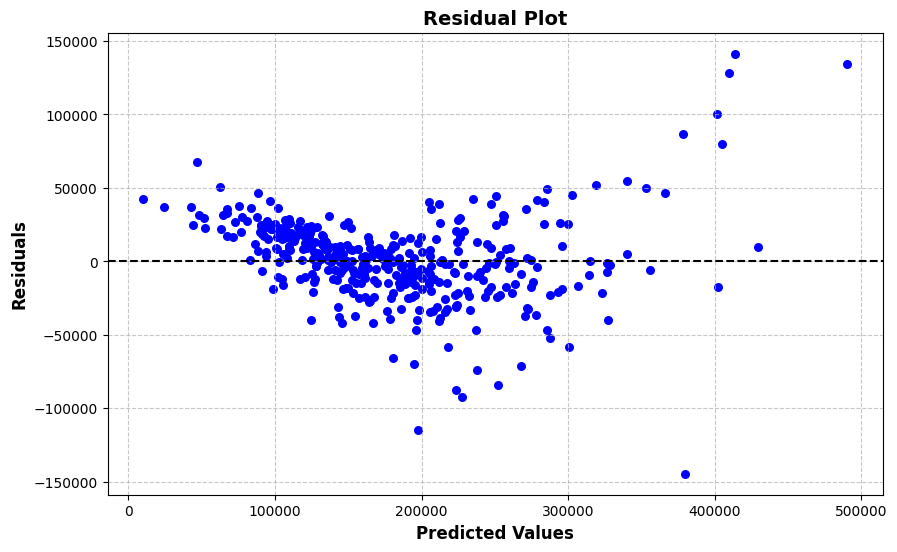

In [ ]:
#Residual Plot for base lr
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y=y_test

res=y-y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, res, color='b', marker='o', s=30)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Values', fontsize=12, fontweight='bold')
plt.ylabel('Residuals', fontsize=12, fontweight='bold')
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

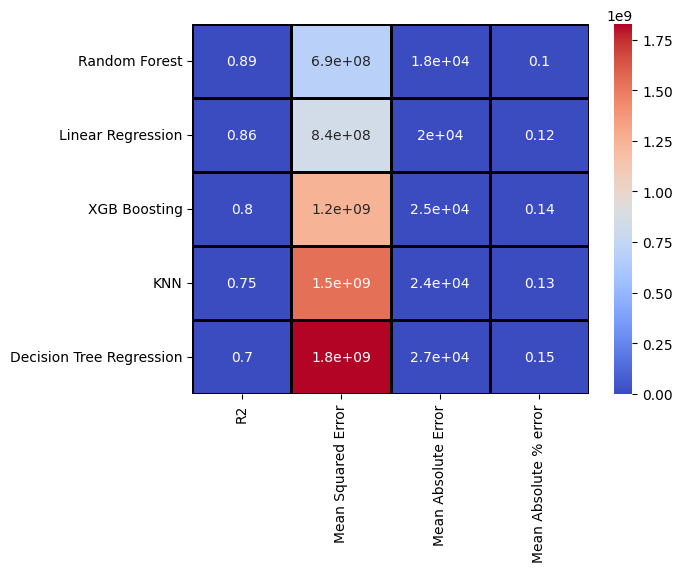

In [ ]:
# Base model fit
model_dic = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regression": DTR(),
    "Random Forest": RFR(),
    "XGB Boosting": XGBRegressor(),
    "KNN": KNeighborsRegressor(),
}

metric_dic={}

for (i, model) in model_dic.items():
    model.fit(X_train.to_numpy(), y_train.to_numpy())
    y_pred = model.predict(X_test.to_numpy())

    metric_dic[i]={'R2':r2_score(y_test,y_pred),
                "Mean Squared Error"  :mean_squared_error(y_test,y_pred),
                "Mean Absolute Error"  :mean_absolute_error(y_test,y_pred),
                "Mean Absolute % error"  :mean_absolute_percentage_error(y_test, y_pred)}

metric_dic=pd.DataFrame(metric_dic)
metric_dic_transposed = metric_dic.T
metric_dic_sorted = metric_dic_transposed.sort_values(by=['R2'],ascending=False)

sns.heatmap(metric_dic_sorted, cmap="coolwarm", annot=True, linecolor="black", linewidths=1)
plt.show()

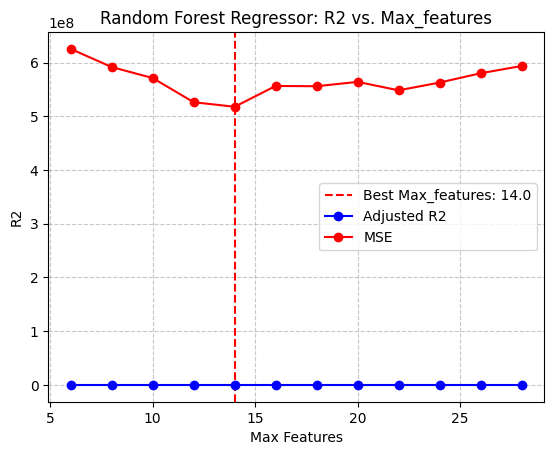

In [ ]:
## Optimizing RandomForestRegressor max_features
fet_vals=range(6,30,2)
adj_r2_scores=[]
mse_scores=[]

for i in fet_vals:
  RF_car = RFR(max_features=i,
            random_state=0).fit(X_train, y_train)
  y_pred = RF_car.predict(X_test)
  r2=r2_score(y_test, y_pred)
  mse_scores.append(mean_squared_error(y_test, y_pred))
  adj_r2_scores.append(1-(((1-r2)*(len(X_test)-1))/(len(X_test)-X_test.shape[1]-1)))

best_K = fet_vals[np.argmax(adj_r2_scores)]

plt.axvline(best_K, color='r', linestyle='--', label=f'Best Max_features: {best_K:.1f}')
plt.plot(fet_vals, adj_r2_scores,marker='o', label='Adjusted R2',color='b')
plt.plot(fet_vals, mse_scores,marker='o', label='MSE',color='r')
plt.xlabel('Max Features')
plt.ylabel('R2')
plt.title('Random Forest Regressor: R2 vs. Max_features')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distributions = {
    'n_estimators': [200,250,300],
    'max_depth': [10,15,20],
    'min_samples_split': [2,3,5],
    'min_samples_leaf': [1,2],
}


rf = RandomForestRegressor(max_features=14,random_state=162)

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_distributions,
                                   n_iter=15, scoring='neg_mean_squared_error',
                                   cv=5, n_jobs=-1, verbose=2, random_state=162)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

# Get the best model
best_rf_model = random_search.best_estimator_

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_depth': 20}
Best score: -996065207.4270351


In [ ]:
importances = best_rf_model.feature_importances_
feature_importances = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

top_10_features = feature_importances.head(10)

print(top_10_features)

         feature  importance
3    OverallQual    0.287289
10     GrLivArea    0.171039
14    GarageCars    0.124735
9    TotalBsmtSF    0.082440
5      YearBuilt    0.077617
6   YearRemodAdd    0.049516
8     BsmtFinSF1    0.046620
2        LotArea    0.036574
13    Fireplaces    0.024179
1    LotFrontage    0.021518


In [ ]:
# FT RF metrics
y_pred = best_rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
bias = np.mean(y_pred - y_test)
max_deviation = np.max(np.abs(y_pred - y_test))
mad = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Print the metrics
print(f"R2: {r2:.4f}")
print(f"Bias: {bias:.4f}")
print(f"Max Deviation: {max_deviation:.4f}")
print(f"MAD: {mad:.4f}")
print(f"MSE: {mse:.4f}")

R2: 0.9114
Bias: -101.1800
Max Deviation: 130432.6733
MAD: 15655.5308
MSE: 538531741.4973


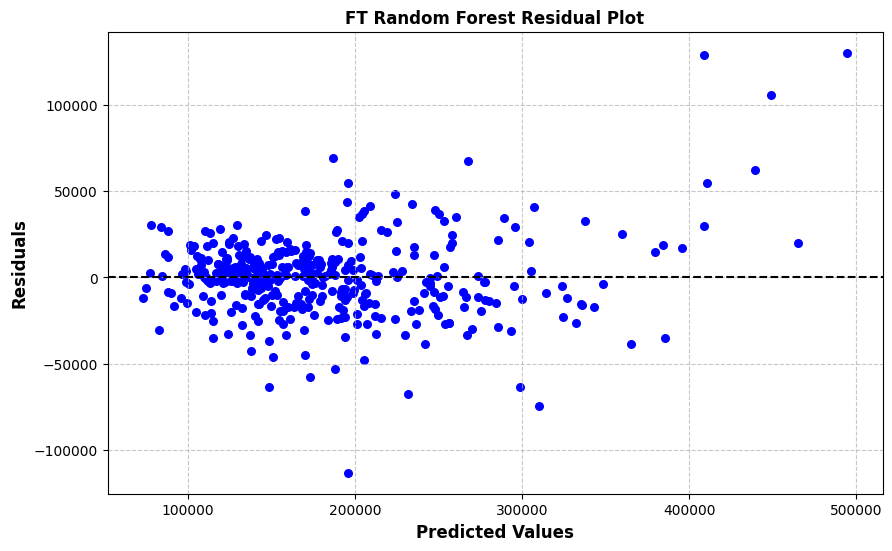

In [ ]:
y_pred = best_rf_model.predict(X_test)
res = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, res, color='b', marker='o', s=30)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Values', fontsize=12, fontweight='bold')
plt.ylabel('Residuals', fontsize=12, fontweight='bold')
plt.title('FT Random Forest Residual Plot', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

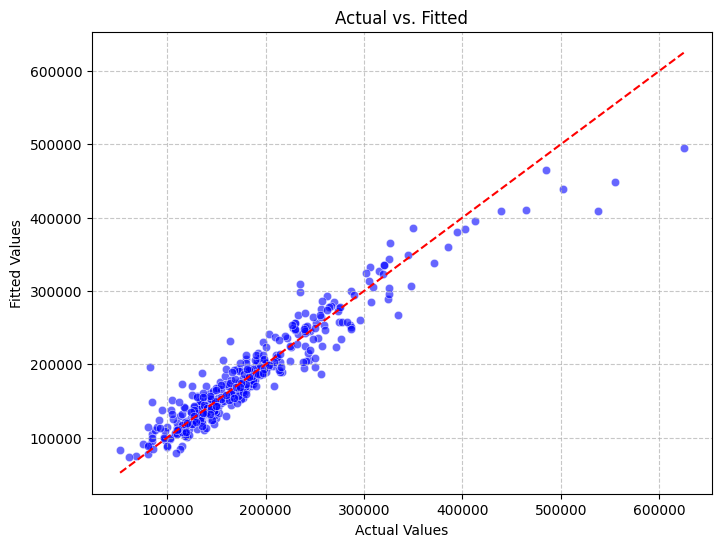

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Fitted Values')
plt.title('Actual vs. Fitted')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

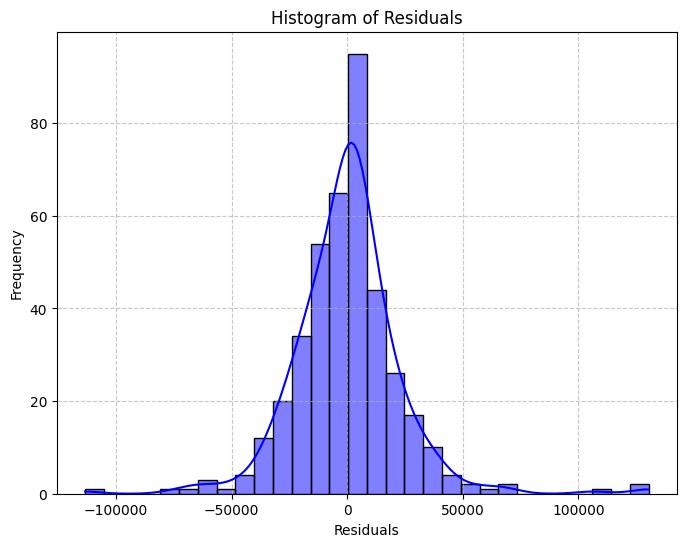

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(res, bins=30, kde=True, color='blue')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


<Figure size 800x600 with 0 Axes>

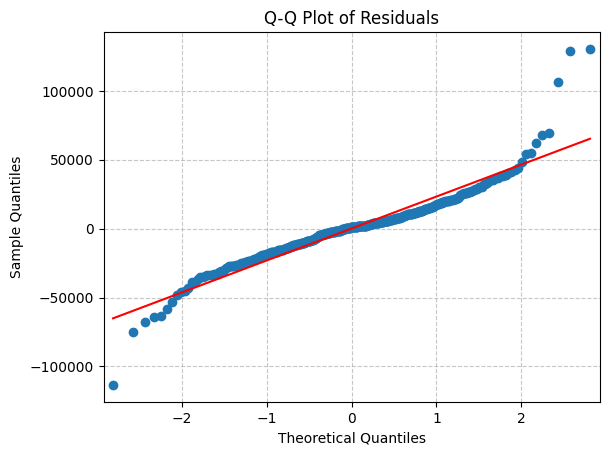

In [ ]:
plt.figure(figsize=(8, 6))
sm.qqplot(res, line='s', color='orange')
plt.title('Q-Q Plot of Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

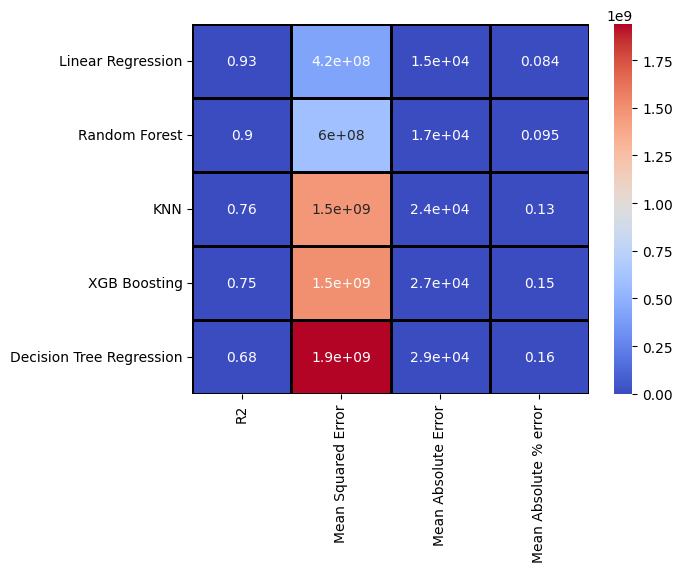

In [ ]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Base LOG model fit
model_dic = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regression": DTR(),
    "Random Forest": RFR(),
    "XGB Boosting": XGBRegressor(),
    "KNN": KNeighborsRegressor(),
}

metric_dic={}

for (i, model) in model_dic.items():
    model.fit(X_train.to_numpy(), y_train_log.to_numpy())
    y_pred_log = model.predict(X_test.to_numpy())
    y_pred = np.expm1(y_pred_log)

    metric_dic[i]={'R2':r2_score(y_test,y_pred),
                "Mean Squared Error"  :mean_squared_error(y_test,y_pred),
                "Mean Absolute Error"  :mean_absolute_error(y_test,y_pred),
                "Mean Absolute % error"  :mean_absolute_percentage_error(y_test, y_pred)}

metric_dic=pd.DataFrame(metric_dic)
metric_dic_transposed = metric_dic.T
metric_dic_sorted = metric_dic_transposed.sort_values(by=['R2'],ascending=False)

sns.heatmap(metric_dic_sorted, cmap="coolwarm", annot=True, linecolor="black", linewidths=1)
plt.show()

In [ ]:
# Gridsearch for log model parameters
from sklearn.model_selection import GridSearchCV

models = {
    'Ridge': {
        'model': Ridge(),
        'param_grid': {'alpha': [0.01,0.1, 1, 10]},
    },
    'Lasso': {
        'model': Lasso(),
        'param_grid': {'alpha': [0.01,0.1, 1, 10]},
    },
    'ElasticNet': {
        'model': ElasticNet(),
        'param_grid': {'alpha': [0.01,0.1, 1, 10], 'l1_ratio': [0.2,0.5, 0.9]},
    },
}

for model_name, model_data in models.items():
    model = model_data['model']
    param_grid = model_data['param_grid']

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=3,
        n_jobs=-1,
    )

    grid_search.fit(X_train, y_train_log)

    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best score for {model_name}: {grid_search.best_score_}")

    best_model = grid_search.best_estimator_

Best parameters for Ridge: {'alpha': 10}
Best score for Ridge: -0.026933924753212407
Best parameters for Lasso: {'alpha': 0.01}
Best score for Lasso: -0.02714701567747088
Best parameters for ElasticNet: {'alpha': 0.01, 'l1_ratio': 0.5}
Best score for ElasticNet: -0.026767559316437522


In [ ]:
# Elastic Net metrics
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

r2 = r2_score(y_test, y_pred)
bias = np.mean(y_pred - y_test)
max_deviation = np.max(np.abs(y_pred - y_test))
mad = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Print the metrics
print(f"R2: {r2:.4f}")
print(f"Bias: {bias:.4f}")
print(f"Max Deviation: {max_deviation:.4f}")
print(f"MAD: {mad:.4f}")
print(f"MSE: {mse:.4f}")

# Best model was ElasticNet with alpha=0.01 and l1_ratio 0.5

R2: 0.9326
Bias: -3889.0518
Max Deviation: 105752.8814
MAD: 14223.2990
MSE: 409423926.4413


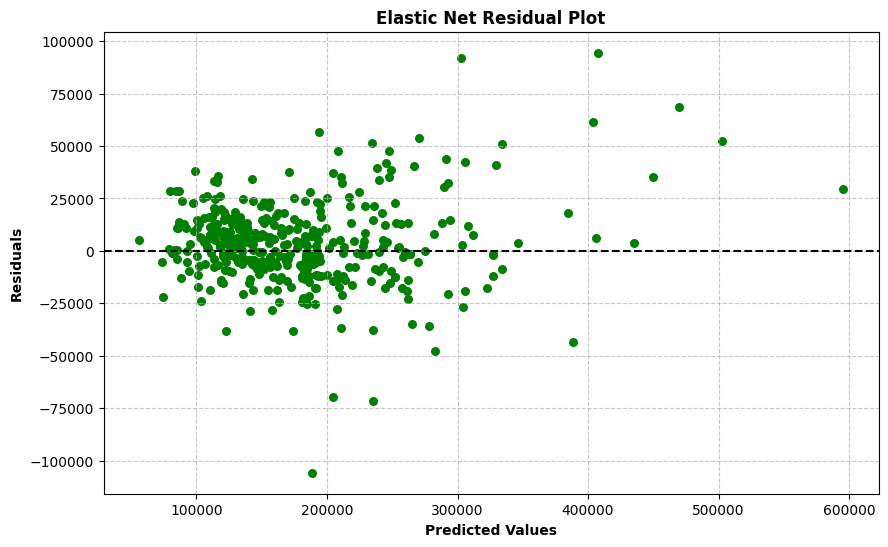

In [ ]:
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

res = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, res, color='g', marker='o', s=30)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Values', fontsize=10, fontweight='bold')
plt.ylabel('Residuals', fontsize=10, fontweight='bold')
plt.title('Elastic Net Residual Plot', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

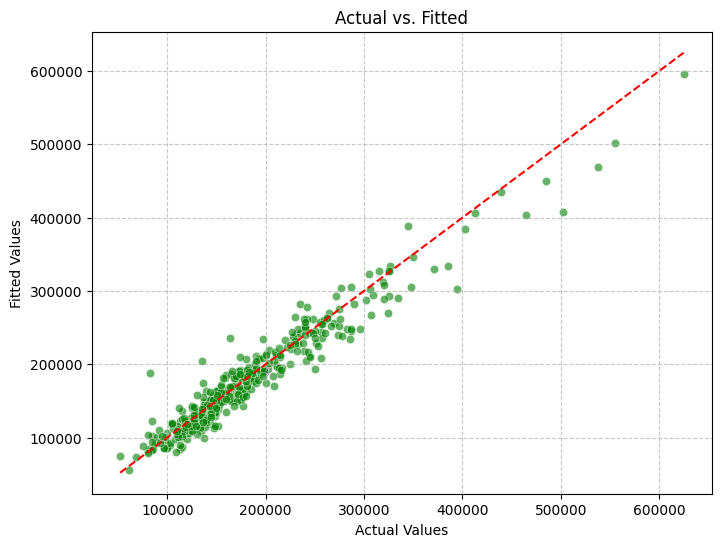

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Fitted Values')
plt.title('Actual vs. Fitted')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

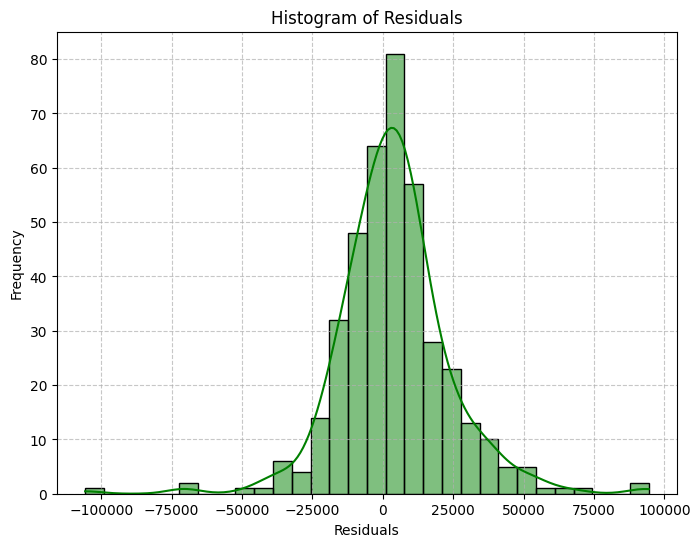

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(res, bins=30, kde=True, color='green')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


<Figure size 800x600 with 0 Axes>

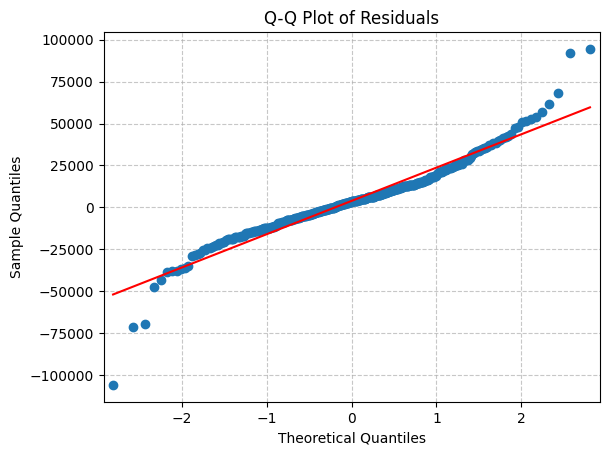

In [ ]:
plt.figure(figsize=(8, 6))
sm.qqplot(res, line='s', color='orange')
plt.title('Q-Q Plot of Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
coefficients = best_model.coef_
coefficients_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': coefficients})
coefficients_df = coefficients_df.reindex(coefficients_df['Coefficient'].abs().sort_values(ascending=False).index)

print(coefficients_df)

         Feature  Coefficient
10     GrLivArea     0.131028
3    OverallQual     0.103235
24   fet_ClyTile    -0.077429
5      YearBuilt     0.057049
14    GarageCars     0.049539
4    OverallCond     0.046483
9    TotalBsmtSF     0.042104
8     BsmtFinSF1     0.037458
18        fet_RL     0.037092
6   YearRemodAdd     0.029851
13    Fireplaces     0.027829
17        fet_FV     0.021773
40   fet_Abnorml    -0.014170
36       fet_Typ     0.013381
2        LotArea     0.012870
12  KitchenAbvGr    -0.011400
39       fet_New     0.011098
1    LotFrontage     0.010925
27    fet_CBlock    -0.009621
15    WoodDeckSF     0.009363
21   fet_CulDSac     0.006344
20       fet_HLS     0.005703
31        fet_No    -0.005666
22       fet_Gtl    -0.004336
11  BedroomAbvGr     0.004053
0     MSSubClass    -0.003181
37       fet_CWD     0.003141
19       fet_Bnk    -0.003013
32      fet_OthW    -0.001328
7     MasVnrArea     0.000000
23     fet_Gable    -0.000000
16      PoolArea     0.000000
26   fet_W